# Preprocesamiento — MetroPT-3 para estimación de RUL

Este notebook transforma los datos crudos del compresor en dos datasets listos para
el modelado de **Remaining Useful Life (RUL)**, tomando decisiones orientadas
específicamente a esa tarea.

## Objetivo y decisiones de diseño

**Contexto del dataset (UCI MetroPT-3):**
- Resolución **nativa de ~10 s** (0.1 Hz). No se remuestrea a 1 min para no destruir
  los transitorios rápidos de presión que caracterizan las fugas de aire.
- 4 fallas conocidas (todas *air leak*, alta severidad) entre abril y julio de 2020.

**Estrategia para RUL — *ciclos hasta falla*:**
1. Los gaps grandes (paros reales del equipo) delimitan **segmentos continuos** = ciclos de vida.
2. Se **preserva el régimen 0 (apagado)** dentro de cada segmento: su duración es parte
   del historial temporal necesario para calcular *tiempo hasta la falla*.
3. Se conservan **todas las señales** (analógicas y binarias): las binarias definen el
   régimen y el ciclado, ambos indicadores de degradación.

**Pipeline:**
1. Cargar datos y parsear timestamps.
2. Verificar frecuencia real y confirmar resolución de 10 s.
3. Detectar gaps grandes → marcar `id_segmento` (ciclos).
4. Verificar que las 4 fallas caen en segmentos con historial suficiente.
5. Regularizar cada segmento a una rejilla exacta de 10 s (sin downsample).
6. Identificar régimen operacional (0=apagado, 1=sin carga, 2=bajo carga).
7. Validar continuidad y calidad.
8. Guardar **dos** salidas:
   - `data/processed/preprocesado_completo.parquet` — todos los regímenes (base para RUL).
   - `data/processed/operacional.parquet` — solo regímenes 1 y 2 (análisis operacional).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')

ANALOG_COLS = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
               'Oil_temperature', 'Motor_current']
BINARY_COLS = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
               'Pressure_switch', 'Oil_level']
COUNTER_COLS = ['Caudal_impulses']

FALLAS = [
    '2020-04-18 00:00',
    '2020-05-29 23:30',
    '2020-06-05 10:00',
    '2020-07-15 14:30',
]

FREC_NATIVA_S = 10   # resolución nativa del dataset (segundos)

## 1. Cargar datos y parsear timestamps

In [2]:
df = pd.read_csv('../data/raw/MetroPT3(AirCompressor).csv',
                 parse_dates=['timestamp'])
df = df.drop(columns=['Unnamed: 0'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Filas y columnas : {df.shape}')
print(f'Rango temporal   : {df["timestamp"].min()}  ->  {df["timestamp"].max()}')
df.head()

Filas y columnas : (1516948, 16)
Rango temporal   : 2020-02-01 00:00:00  ->  2020-09-01 03:59:50


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 2. Verificar frecuencia real

Confirmamos que la resolución nativa es de ~10 s. Este es el dataset oficial de UCI;
trabajaremos a esta resolución sin submuestrear.

In [3]:
diferencias = df['timestamp'].diff().dt.total_seconds()

print('Frecuencia predominante (segundos):')
print(diferencias.value_counts().head(8))

print(f'\nGaps mayores a 30 s : {(diferencias > 30).sum()}')
print(f'Gap máximo          : {diferencias.max()/3600:.0f} horas')
print(f'\nResolución nativa asumida: {FREC_NATIVA_S} s')

Frecuencia predominante (segundos):
timestamp
10.0    1337521
9.0      128277
12.0      38321
13.0       7988
11.0       4471
21.0         10
19.0          5
22.0          4
Name: count, dtype: int64

Gaps mayores a 30 s : 331
Gap máximo          : 48 horas

Resolución nativa asumida: 10 s


## 3. Detectar gaps y crear segmentos (ciclos de vida)

Un gap grande entre muestras indica un **paro real** del equipo, no un error de registro.
Cada tramo continuo entre gaps es un **segmento** que usaremos como unidad de ciclo de vida
para la etiqueta RUL. La variación normal de muestreo llega hasta ~13 s, por lo que un umbral
de 60 s es un margen seguro para separar paros reales de jitter del sensor.

In [4]:
GAP_SEGMENTO_S = 60  # segundos; por encima de esto se considera fin de ciclo

df['diff_segundos'] = df['timestamp'].diff().dt.total_seconds()
df['nuevo_segmento'] = df['diff_segundos'] > GAP_SEGMENTO_S
df['id_segmento'] = df['nuevo_segmento'].cumsum()

print(f'Total de segmentos (ciclos): {df["id_segmento"].nunique()}')

Total de segmentos (ciclos): 332


In [5]:
# Duración de cada segmento en minutos (a resolución nativa de 10 s)
dur_min = df.groupby('id_segmento').size() * FREC_NATIVA_S / 60

print('Duración de los segmentos (minutos):')
print(dur_min.describe())
print(f'\nSegmentos < 10 min : {(dur_min < 10).sum()}')
print(f'Segmentos > 6 h    : {(dur_min > 360).sum()}')

Duración de los segmentos (minutos):
count     332.000000
mean      761.520080
std       957.510374
min         4.833333
25%        25.000000
50%       389.833333
75%      1205.000000
max      6099.833333
dtype: float64

Segmentos < 10 min : 41
Segmentos > 6 h    : 170


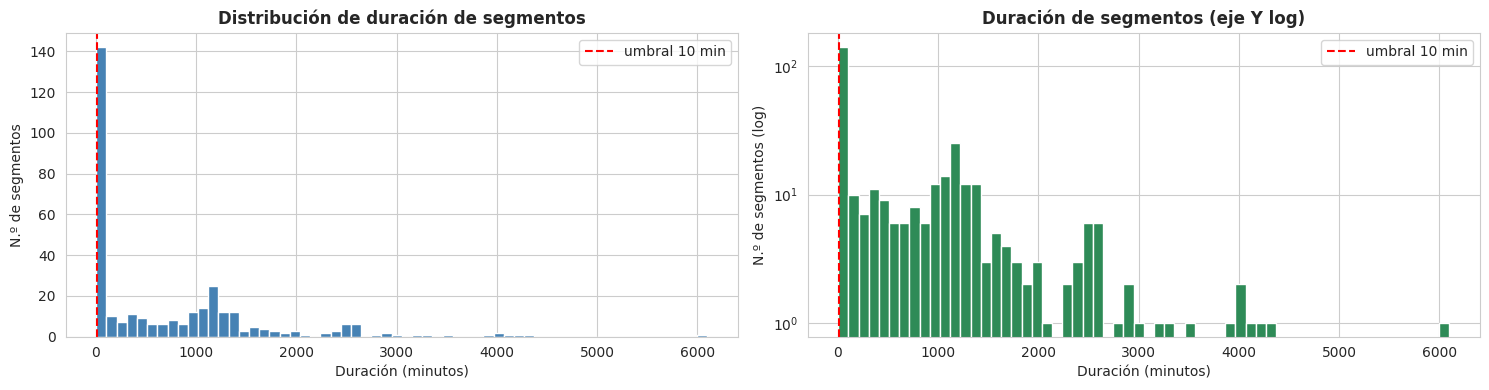

In [6]:
# Visualización de la distribución de duración de segmentos
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(dur_min, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(10, color='red', linestyle='--', label='umbral 10 min')
axes[0].set_title('Distribución de duración de segmentos', fontweight='bold')
axes[0].set_xlabel('Duración (minutos)')
axes[0].set_ylabel('N.º de segmentos')
axes[0].legend()

# Escala log para ver la cola larga
axes[1].hist(dur_min, bins=60, color='seagreen', edgecolor='white')
axes[1].set_yscale('log')
axes[1].axvline(10, color='red', linestyle='--', label='umbral 10 min')
axes[1].set_title('Duración de segmentos (eje Y log)', fontweight='bold')
axes[1].set_xlabel('Duración (minutos)')
axes[1].set_ylabel('N.º de segmentos (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Nota para RUL:** no descartamos aquí los segmentos cortos. Todos se conservan en el
parquet completo; el filtrado por duración mínima se hará al construir las ventanas
deslizantes (notebook 06), cuando se conozca el tamaño de ventana definitivo.

## 4. ¿Las fallas caen en segmentos con historial suficiente?

In [7]:
dur_min = df.groupby('id_segmento').size() * FREC_NATIVA_S / 60

for falla in FALLAS:
    ts = pd.Timestamp(falla)
    seg = df[df['timestamp'] <= ts]['id_segmento'].iloc[-1]
    print(f'Falla {falla} -> segmento {seg} (duración {dur_min[seg]:.0f} min)')

Falla 2020-04-18 00:00 -> segmento 112 (duración 1029 min)


Falla 2020-05-29 23:30 -> segmento 181 (duración 1645 min)
Falla 2020-06-05 10:00 -> segmento 191 (duración 4028 min)


Falla 2020-07-15 14:30 -> segmento 252 (duración 1205 min)


Las 4 fallas caen en segmentos largos (> 17 h), con historial más que suficiente para
construir ventanas y una curva de RUL descendente antes del evento.

### Visualización de un ciclo con falla

Graficamos las señales clave del segmento que contiene la falla del 2020-06-05
(el más largo, ~67 h) para ver la evolución de presión, corriente y temperatura
en las horas previas al evento.

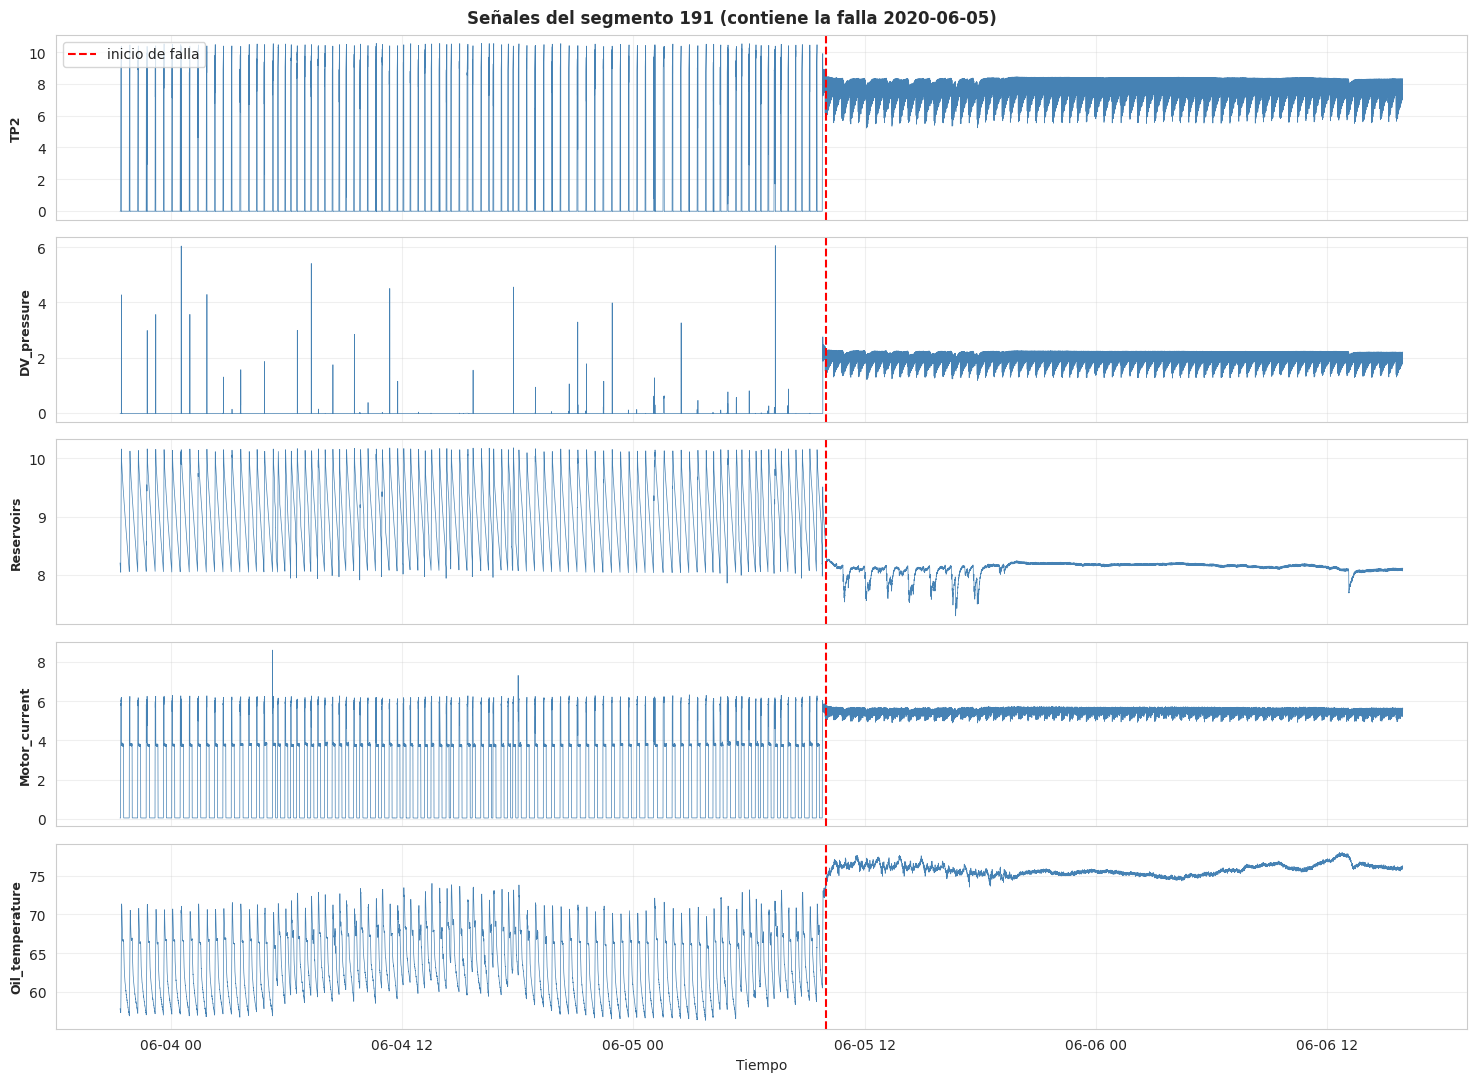

In [8]:
# Señales de un segmento con falla (el de la falla del 5-jun, segmento más largo)
ts_falla = pd.Timestamp('2020-06-05 10:00')
seg_falla = df[df['timestamp'] <= ts_falla]['id_segmento'].iloc[-1]
sub = df[df['id_segmento'] == seg_falla]

sensores_plot = ['TP2', 'DV_pressure', 'Reservoirs', 'Motor_current', 'Oil_temperature']
fig, axes = plt.subplots(len(sensores_plot), 1, figsize=(15, 11), sharex=True)

for ax, col in zip(axes, sensores_plot):
    ax.plot(sub['timestamp'], sub[col], linewidth=0.5, color='steelblue')
    ax.axvline(ts_falla, color='red', linestyle='--', linewidth=1.5,
               label='inicio de falla' if col == sensores_plot[0] else None)
    ax.set_ylabel(col, fontweight='bold', fontsize=9)
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper left')
axes[-1].set_xlabel('Tiempo')
plt.suptitle(f'Señales del segmento {seg_falla} (contiene la falla 2020-06-05)',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Regularizar cada segmento a una rejilla exacta de 10 s

En lugar de submuestrear (que promediaría y borraría transitorios), **regularizamos** la
rejilla temporal: pasamos de intervalos irregulares (9–13 s) a una rejilla exacta de 10 s
dentro de cada segmento. Esto preserva la máxima resolución disponible.

- **Analógicas:** `mean` (dentro de cada bin de 10 s hay típicamente 1 muestra, así que no
  se pierde información; solo se alinea a la rejilla).
- **Binarias:** último valor observado (`last`) — refleja el estado vigente del sensor.
- **Contador (`Caudal_impulses`):** `sum` — suma pulsos detectados dentro del bin.
  Nota: después del resample, `Caudal_impulses` ya no es binaria (0/1) — puede tomar
  valores ≥ 1 si hubo múltiples pulsos en el intervalo de 10 s.

Los huecos internos (hasta 20 s = 2 bins) se interpolan; huecos mayores se dejan como
frontera y se eliminan las filas totalmente vacías.

In [9]:
agg_func = {c: 'mean' for c in ANALOG_COLS}
agg_func.update({c: 'last' for c in BINARY_COLS})
agg_func.update({c: 'sum' for c in COUNTER_COLS})

INTERP_LIMIT_BINS = 2  # 2 bins de 10 s = hasta 20 s de hueco interno

segmentos = []
n_interp_total = 0
for id_seg, grupo in df.groupby('id_segmento'):
    g = grupo.set_index('timestamp')[ANALOG_COLS + BINARY_COLS + COUNTER_COLS]
    reg = g.resample(f'{FREC_NATIVA_S}s').agg(agg_func)

    n_antes = reg[ANALOG_COLS].isna().sum().sum()
    reg[ANALOG_COLS] = reg[ANALOG_COLS].interpolate(method='time', limit=INTERP_LIMIT_BINS)
    reg[BINARY_COLS] = reg[BINARY_COLS].ffill(limit=INTERP_LIMIT_BINS)
    reg[COUNTER_COLS] = reg[COUNTER_COLS].fillna(0)
    n_interp_total += n_antes - reg[ANALOG_COLS].isna().sum().sum()

    reg = reg.dropna()
    reg['id_segmento'] = id_seg
    segmentos.append(reg)

df_reg = pd.concat(segmentos).reset_index()
print(f'Valores analógicos interpolados: {int(n_interp_total):,}')
print(f'Filas tras regularizar a 10 s   : {len(df_reg):,}')
print(f'Reducción vs crudo              : {len(df)/len(df_reg):.2f}x')
df_reg.head()

Valores analógicos interpolados: 73,857
Filas tras regularizar a 10 s   : 1,514,658
Reducción vs crudo              : 1.00x


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,id_segmento
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.6000,0.04000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
1,2020-02-01 00:00:10,-0.013,9.343,9.327,-0.022,9.343,53.6375,0.04125,1.0,0.0,1.0,1.0,0.0,1.0,1.0,2.0,0
2,2020-02-01 00:00:20,-0.012,9.328,9.312,-0.022,9.328,53.4250,0.04000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
3,2020-02-01 00:00:30,-0.012,9.318,9.302,-0.022,9.318,53.4750,0.04000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0
4,2020-02-01 00:00:40,-0.012,9.306,9.290,-0.024,9.308,53.5000,0.04000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0


In [10]:
# Distribución de la interpolación aplicada por segmento
interp_por_seg = (df_reg.groupby('id_segmento').size()
                  .rename('filas_finales').to_frame())
print('Filas finales por segmento (resumen):')
print(interp_por_seg['filas_finales'].describe().round(1))
print(f'\nTotal de valores analógicos interpolados: {int(n_interp_total):,} '
      f'({n_interp_total / (len(df_reg) * len(ANALOG_COLS)) * 100:.3f}% del total)')

Filas finales por segmento (resumen):
count      332.0
mean      4562.2
std       5752.4
min         28.0
25%        148.8
50%       2318.5
75%       7167.2
max      36280.0
Name: filas_finales, dtype: float64

Total de valores analógicos interpolados: 73,857 (0.697% del total)


## 6. Identificar régimen operacional

Según la documentación del dataset (Motor_current ≈ 0A apagado, 4A sin carga, 7A bajo carga,
9A arranque) y las señales digitales:

| Estado | régimen | DV_electric | Motor_current |
|--------|---------|-------------|---------------|
| APAGADO | 0 | 0 | ≈ 0 A |
| SIN CARGA | 1 | 0 | > 2 A |
| BAJO CARGA | 2 | 1 | > 2 A |

El umbral `Motor_current > 2A` separa robustamente el estado apagado del operativo.
**Conservamos el régimen 0** para no romper la continuidad temporal que necesita RUL.

In [11]:
df_reg['regimen'] = 0  # APAGADO
df_reg.loc[(df_reg['DV_eletric'] == 0) & (df_reg['Motor_current'] > 2), 'regimen'] = 1
df_reg.loc[(df_reg['DV_eletric'] == 1) & (df_reg['Motor_current'] > 2), 'regimen'] = 2

print(df_reg['regimen'].value_counts().sort_index())
print(f'\nProporción operativa (1+2): {(df_reg["regimen"] != 0).mean()*100:.1f} %')

regimen
0    826950
1    444081
2    243627
Name: count, dtype: int64

Proporción operativa (1+2): 45.4 %


## 7. Validación de datos procesados

In [12]:
print('=== VALIDACIÓN (dataset completo) ===\n')

nulos = df_reg.isnull().sum().sum()
print(f'1. Valores nulos            : {nulos} {"OK" if nulos == 0 else "FALLA"}')

ordenado = df_reg.sort_values(['id_segmento', 'timestamp']).equals(df_reg)
print(f'2. Ordenado por segmento/ts : {ordenado} {"OK" if ordenado else "FALLA"}')

regs_ok = set(df_reg['regimen'].unique()) <= {0, 1, 2}
print(f'3. Regímenes en {{0,1,2}}     : {regs_ok} {"OK" if regs_ok else "FALLA"}')

# Verificar que las fallas siguen presentes (búsqueda por timestamp más cercano, ±10 s)
print('\n4. Fallas presentes en los datos:')
for falla in FALLAS:
    ts = pd.Timestamp(falla)
    idx_cercano = (df_reg['timestamp'] - ts).abs().argsort().iloc[0]
    cercano = df_reg['timestamp'].iloc[idx_cercano]
    distancia = abs((cercano - ts).total_seconds())
    presente = distancia <= 10
    print(f'   {falla}: {presente} (más cercana: {cercano}, Δ={distancia:.0f} s)')

print('\n=== RESUMEN ===')
print(f'Registros : {len(df_reg):,}')
print(f'Segmentos : {df_reg["id_segmento"].nunique()}')
print(f'Período   : {df_reg["timestamp"].min()} a {df_reg["timestamp"].max()}')

=== VALIDACIÓN (dataset completo) ===

1. Valores nulos            : 0 OK


2. Ordenado por segmento/ts : True OK
3. Regímenes en {0,1,2}     : True OK

4. Fallas presentes en los datos:
   2020-04-18 00:00: True
   2020-05-29 23:30: True
   2020-06-05 10:00: True
   2020-07-15 14:30: True

=== RESUMEN ===
Registros : 1,514,658
Segmentos : 332
Período   : 2020-02-01 00:00:00 a 2020-09-01 03:59:50


## 8. Definir sesiones operacionales y elegir el umbral

Para el `operacional.parquet` (regímenes 1 y 2) agrupamos la operación en **sesiones**:
tramos de operación separados por pausas. Un gap operativo grande indica que el equipo
se detuvo entre dos usos. Elegimos el umbral analizando la distribución de los gaps
entre muestras operativas.

In [13]:
# Construir dataset operacional (regímenes 1 y 2) y medir gaps entre muestras
df_op = df_reg[df_reg['regimen'] != 0].sort_values('timestamp').reset_index(drop=True)
df_op['diff_minutos'] = df_op['timestamp'].diff().dt.total_seconds() / 60

gaps = df_op['diff_minutos'].dropna()
print('Distribución de gaps operativos (minutos):')
print(gaps.describe().round(2))

# Guardar el umbral como constante para reutilizar en la celda de guardado
GAP_SESION_MIN = 30.0

Distribución de gaps operativos (minutos):
count    687707.00
mean          0.45
std           8.78
min           0.17
25%           0.17
50%           0.17
75%           0.17
max        2935.67
Name: diff_minutos, dtype: float64


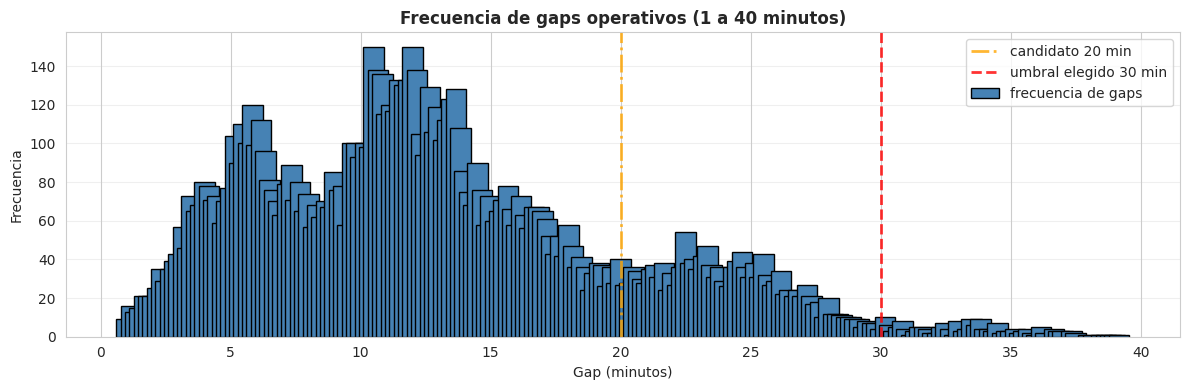

In [ ]:
# Justificación visual del umbral de sesión
os.makedirs('../img/umbral', exist_ok=True)

frec = gaps.value_counts().sort_index()
frec_zoom = frec[(frec.index >= 1) & (frec.index <= 40)]

plt.figure(figsize=(12, 4))
plt.bar(frec_zoom.index, frec_zoom.values, color='steelblue',
        edgecolor='black', width=0.8, label='frecuencia de gaps')
plt.axvline(20, color='orange', linestyle='-.', linewidth=2, alpha=0.8,
                label='candidato 20 min')
plt.axvline(30, color='red', linestyle='--', linewidth=2, alpha=0.8,
                label='umbral elegido 30 min')
plt.title('Frecuencia de gaps operativos (1 a 40 minutos)', fontweight='bold')
plt.xlabel('Gap (minutos)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../img/umbral/umbrales_cambio_sesion.png', dpi=150, bbox_inches='tight')
plt.show()

Tras el minuto 20 aún hay una cantidad considerable de gaps (pausas cortas de operación
que no representan un cambio real de sesión). A partir de **30 minutos** la frecuencia cae
a niveles despreciables, por lo que ese valor separa de forma robusta pausas operativas
normales de verdaderos cambios de sesión. Se elige **`GAP_SESION_MIN = 30`**.

## 9. Guardar salidas

- **`preprocesado_completo.parquet`**: todos los regímenes con `id_segmento`. Base para la
  etiqueta RUL (*tiempo hasta la falla*) respetando la continuidad temporal.
- **`operacional.parquet`**: regímenes 1 y 2 con `id_sesion`.

In [15]:
os.makedirs('../data/processed', exist_ok=True)

# 1) Dataset completo (base para RUL)
df_reg.to_parquet('../data/processed/preprocesado_completo.parquet',
                  engine='fastparquet', index=False)
print(f'preprocesado_completo.parquet : {len(df_reg):,} registros')

# 2) Dataset operacional con id_sesion según el umbral elegido
df_op['id_sesion'] = (df_op['diff_minutos'] > GAP_SESION_MIN).cumsum()
df_op = df_op.drop(columns='diff_minutos')

df_op.to_parquet('../data/processed/operacional.parquet',
                 engine='fastparquet', index=False)
print(f'operacional.parquet           : {len(df_op):,} registros, '
      f'{df_op["id_sesion"].nunique()} sesiones')

preprocesado_completo.parquet : 1,514,658 registros


operacional.parquet           : 687,708 registros, 374 sesiones


## 10. Resumen del pipeline

In [16]:
resumen = pd.DataFrame({
    'Etapa': ['Datos crudos (10 s)', 'Regularizado a rejilla 10 s',
              'Operacional (rég. 1 y 2)'],
    'Registros': [len(df), len(df_reg), len(df_op)],
})
resumen['% del crudo'] = (resumen['Registros'] / len(df) * 100).round(1)
print(resumen.to_string(index=False))

                      Etapa  Registros  % del crudo
        Datos crudos (10 s)    1516948        100.0
Regularizado a rejilla 10 s    1514658         99.8
   Operacional (rég. 1 y 2)     687708         45.3


## 11. Conclusiones

**Decisiones tomadas (orientadas a RUL):**

1. **Resolución nativa de 10 s conservada.** Solo se regularizó la rejilla temporal; no se
   submuestreó a 1 min. Esto preserva los transitorios rápidos de presión que caracterizan
   las fugas de aire.

2. **Régimen 0 (apagado) preservado.** Se mantiene la continuidad temporal dentro de cada
   segmento, indispensable para calcular *tiempo hasta la falla*.

3. **Segmentación por gaps > 60 s.** Cada segmento continuo es un ciclo de vida; los gaps
   grandes marcan paros reales del equipo.

4. **Todas las señales conservadas.** Las binarias aportan el régimen y el ciclado, ambos
   predictores de degradación.

5. **Dos salidas generadas.** Un parquet completo (base para RUL) y uno operacional
   (análisis del notebook 03).

**Pendiente de decidir con evidencia (notebook 03/04):**
- Definición exacta de la etiqueta RUL y `RUL_MAX`.
- Tamaño de ventana (a partir de la autocorrelación).
- Estrategia de normalización.
- Descarte de segmentos cortos (al construir ventanas, notebook 06).